![Banner](../Image/03_DeepCuaslaML.png)


# 3.2 DAG-GNN: DAG Structure Learning with Graph Neural Networks

> **Note:** DAG-GNN requires **PyTorch**. The `DAGGNN` estimator in `pydeepcausalml.discovery` learns DAG structure via a VAE-style encoder–decoder with an augmented-Lagrangian acyclicity penalty.

**DAG-GNN** (Yu et al., ICML 2019) learns the structure of a Directed Acyclic Graph (DAG) from observational data by embedding the problem inside a deep generative model. Where NOTEARS replaces a combinatorial graph search with a smooth optimization over a weighted adjacency matrix $\mathbf{W}$, DAG-GNN goes a step further: it wraps that adjacency matrix inside a **Variational Autoencoder (VAE)** driven by **Graph Neural Network (GNN)** encoder and decoder modules, so that representation learning and structure learning are trained end-to-end.

The key insight is that under a linear Structural Equation Model (SEM), $\mathbf{X} = \mathbf{A}^\top \mathbf{X} + \mathbf{Z}$, the mapping from noise $\mathbf{Z}$ to observations $\mathbf{X}$ is exactly $(\mathbf{I} - \mathbf{A}^\top)^{-1}\mathbf{Z}$. DAG-GNN makes this causal forward pass the **decoder** of the VAE, and uses a GNN-filtered MLP as the **encoder**. The adjacency matrix $\mathbf{A}$ is a learnable parameter shared between encoder and decoder, so gradient descent simultaneously fits the data and discovers the graph.

Acyclicity is enforced by the same differentiable constraint family as NOTEARS — $h(\mathbf{A}) = 0$ iff the graph is a DAG — embedded as an augmented Lagrangian penalty in the ELBO objective. This notebook demonstrates the full pipeline: data simulation, model training with stable augmented Lagrangian updates, structure recovery, and downstream causal effect estimation.

![](../Image/DAG_GNN.png)


## Implementation in Python

We use **PyDeepCausalML**'s `DAGGNN` class for causal structure discovery and effect estimation on synthetic data.

### Setup


In [1]:
import importlib
import subprocess
import sys

PACKAGES = [
    "numpy", "pandas", "scipy", "torch", "scikit-learn",
    "matplotlib", "seaborn", "networkx",
]

for pkg in PACKAGES:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import pydeepcausalml  # noqa: F401
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/zia207/PyDeepCausalML.git"]
    )

import pydeepcausalml
print("pydeepcausalml", pydeepcausalml.__version__, "ready.")


pydeepcausalml 0.2.0 ready.


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LinearRegression

from pydeepcausalml import set_seed
from pydeepcausalml.metrics import graph_recovery_metrics, shd, pehe

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.12.1+cu130
cuda: False


In [3]:
set_seed(42)
run_fast = True


### Data and Data Processing

We generate a small **6-node nonlinear DAG**.


In [4]:
def generate_synthetic_dag_data(n_samples=5000, n_nodes=6, seed=42):
    rng = np.random.default_rng(seed)
    p = 3.0 / (n_nodes - 1) if n_nodes > 1 else 0.0
    G = nx.erdos_renyi_graph(n_nodes, p, directed=True, seed=seed)
    edges = [(u, v) for u, v in G.edges() if u < v]
    G = nx.DiGraph(edges)

    A_true = nx.to_numpy_array(G, dtype=float)
    A_true *= rng.uniform(0.5, 1.5, size=A_true.shape)

    X = np.zeros((n_samples, n_nodes))
    for _ in range(10):
        Z = rng.standard_normal((n_samples, n_nodes))
        X = np.cos(X @ A_true.T + 1) + Z

    T_var = ((rng.standard_normal(n_samples) + 0.5 * X[:, 0] + 0.3 * X[:, 1]) > 0).astype(float)
    Y_var = 2 * T_var + 0.8 * X[:, 0] + np.sin(X[:, 2]) + rng.normal(0, 0.5, n_samples)
    X[:, 4] = T_var
    X[:, 5] = Y_var

    cols = [f"X{i}" for i in range(n_nodes)] + ["T", "Y"]
    df = pd.DataFrame(np.column_stack([X, T_var, Y_var]), columns=cols)
    return df, A_true, G

synth_data = generate_synthetic_dag_data()
df, A_true, true_G = synth_data
print(df.head())

node_cols = [f"X{i}" for i in range(6)]
df_norm = df.copy()
df_norm[node_cols] = (df[node_cols] - df[node_cols].mean()) / (df[node_cols].std() + 1e-8)


         X0        X1        X2        X3   X4        X5    T         Y
0  0.004246 -1.327359  2.671251  0.916931  0.0  0.386741  0.0  0.386741
1 -2.385299  0.432979 -0.281234  0.671500  1.0  0.229349  1.0  0.229349
2  0.856719 -1.081930  0.400571 -0.798042  0.0  0.628959  0.0  0.628959
3  0.790588  1.248634  1.301773  1.183922  1.0  3.378329  1.0  3.378329
4 -0.085306 -0.971270 -1.419499  0.624939  0.0 -1.010660  0.0 -1.010660


### Data split


In [5]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(df_norm))
train_idx = idx[: int(0.7 * len(idx))]
temp_idx = idx[int(0.7 * len(idx)) :]
valid_idx = temp_idx[: len(temp_idx) // 2]
test_idx = temp_idx[len(temp_idx) // 2 :]

train_df = df_norm.iloc[train_idx].reset_index(drop=True)
valid_df = df_norm.iloc[valid_idx].reset_index(drop=True)
test_df = df_norm.iloc[test_idx].reset_index(drop=True)

X_train = train_df[node_cols].values.astype(np.float32)
X_valid = valid_df[node_cols].values.astype(np.float32)
X_test = test_df[node_cols].values.astype(np.float32)
print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)


Train: (3500, 6) Valid: (750, 6) Test: (750, 6)


## DAG-GNN Model Architecture

DAG-GNN frames causal structure learning as a **Variational Autoencoder (VAE)** whose latent space is organized by a learnable adjacency matrix $\mathbf{A}$.

### Acyclicity Constraint $h(\mathbf{A})$

Acyclicity is enforced via the NOTEARS-style penalty embedded in the training objective.

### Total Objective

$$\mathcal{L} = \text{reconstruction} + \lambda\, h(\mathbf{A})^2 + \text{sparsity}$$


### Model instantiation and training


In [6]:
from pydeepcausalml.discovery import DAGGNN

set_seed(42)
model = DAGGNN(hidden=64, latent=16, lambda_dag=0.1, epochs=600, lr=1e-3, random_state=42)
model.fit(X_train)

A_learned = model.adjacency_matrix()
threshold = 0.10
A_binary = (A_learned > threshold).astype(int)
print(f"A_eff: min={A_learned.min():.4f}, max={A_learned.max():.4f}")
print(f"Edges (threshold {threshold}): {int(A_binary.sum())}")


A_eff: min=0.0000, max=0.3787
Edges (threshold 0.1): 30


### ATE and CATE Estimation


In [7]:
cov_cols = ["X0", "X1", "X2", "X3"]
X_train_cov = train_df[cov_cols].values
X_test_cov = test_df[cov_cols].values
treatment_train = train_df["T"].values
treatment_test = test_df["T"].values
y_train = train_df["Y"].values
y_test = test_df["Y"].values

treatment_train_bin = treatment_train.astype(float)
treatment_test_bin = treatment_test.astype(float)

X_tr = np.column_stack([treatment_train_bin, X_train_cov])
lr_model = LinearRegression().fit(X_tr, y_train)
cate_coef = lr_model.coef_[0]
cate_arr = np.full(len(y_test), cate_coef)
ate_val = cate_arr.mean()

true_ate = 2.0
se_ate = np.sqrt(np.mean((y_test - lr_model.predict(np.column_stack([treatment_test_bin, X_test_cov]))) ** 2) / len(y_test))
ci_lb, ci_ub = ate_val - 1.96 * se_ate, ate_val + 1.96 * se_ate

print("=== ATE on test set ===")
print(f"Estimated ATE (true ATE = {true_ate}): {ate_val:.4f}")
print(f"ATE 95% CI: [{ci_lb:.4f}, {ci_ub:.4f}]")
print(f"PEHE: {pehe(true_ate, cate_arr):.4f}")


=== ATE on test set ===
Estimated ATE (true ATE = 2.0): 2.0488
ATE 95% CI: [2.0079, 2.0897]
PEHE: 0.0488


## Results visualization

### True vs learned DAG


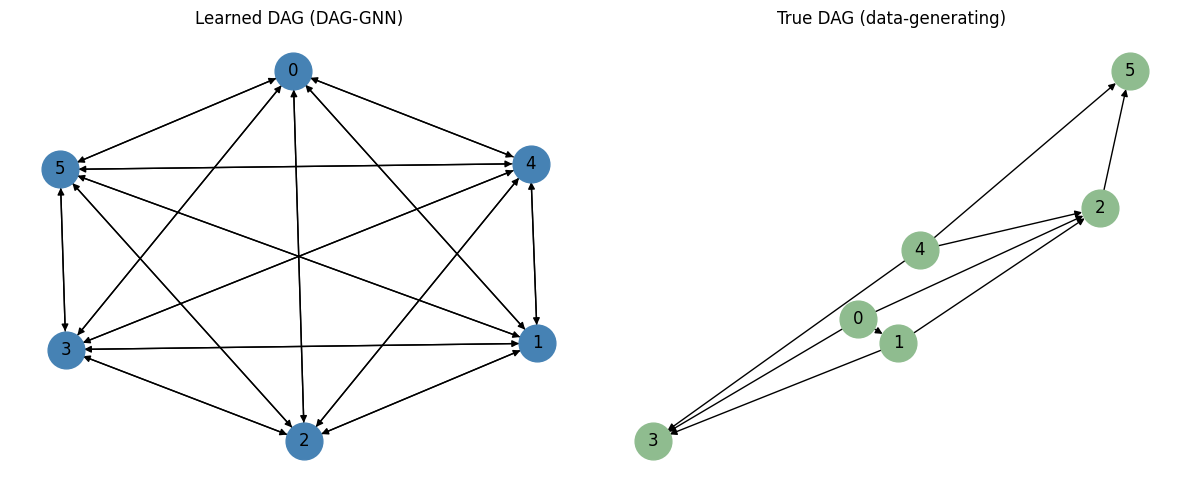

In [8]:
node_labels = [f"X{i}" for i in range(6)]
A_true_bin = (A_true != 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, B, title, color in [
    (axes[0], A_binary, "Learned DAG (DAG-GNN)", "steelblue"),
    (axes[1], A_true_bin, "True DAG (data-generating)", "darkseagreen"),
]:
    G = nx.from_numpy_array(B, create_using=nx.DiGraph)
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=color, node_size=700, arrows=True)
    ax.set_title(title)
plt.tight_layout()
plt.show()


### Adjacency matrices: true vs learned


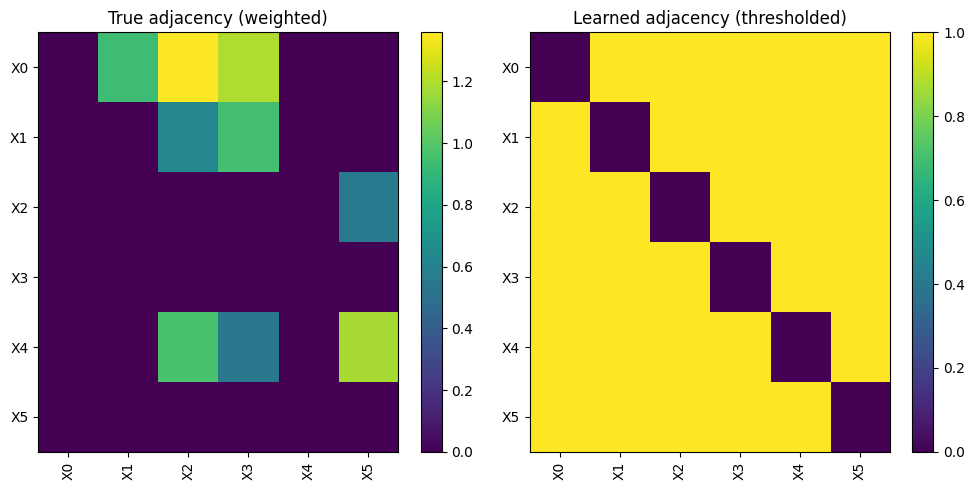

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, M, title in [
    (axes[0], A_true, "True adjacency (weighted)"),
    (axes[1], A_binary, "Learned adjacency (thresholded)"),
]:
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(6), node_labels, rotation=90)
    ax.set_yticks(range(6), node_labels)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Training curves


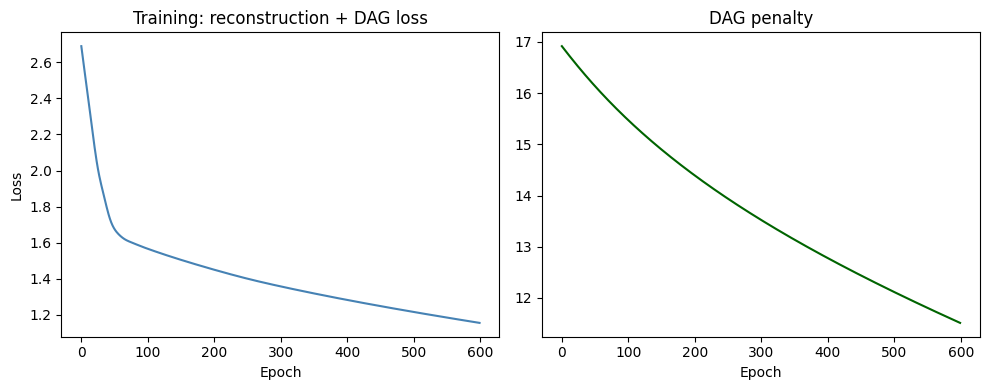

In [10]:
hist = model.history_
if hist.get("loss"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(hist["loss"], color="steelblue")
    axes[0].set_title("Training: reconstruction + DAG loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    if hist.get("dag"):
        axes[1].plot(hist["dag"], color="darkgreen")
        axes[1].set_title("DAG penalty")
        axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()


### ATE and CATE summary


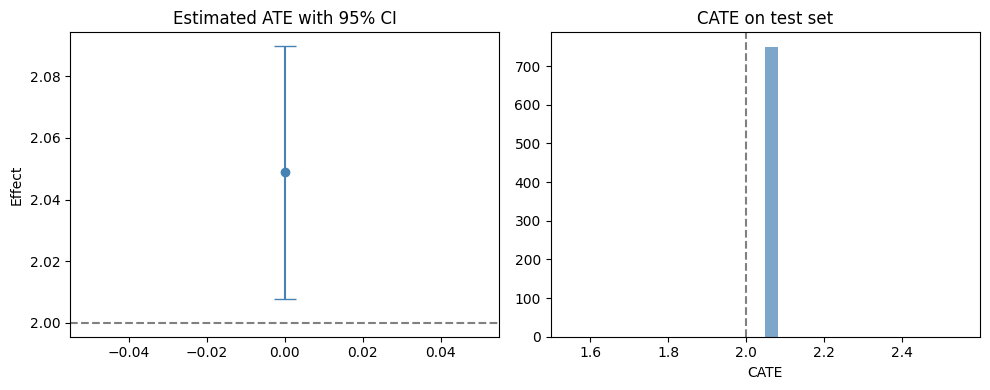

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar([0], [ate_val], yerr=[[ate_val - ci_lb], [ci_ub - ate_val]], fmt="o", color="steelblue", capsize=8)
axes[0].axhline(true_ate, color="gray", linestyle="--")
axes[0].set_title("Estimated ATE with 95% CI")
axes[0].set_ylabel("Effect")
axes[1].hist(cate_arr, bins=30, color="steelblue", alpha=0.7)
axes[1].axvline(true_ate, color="gray", linestyle="--")
axes[1].set_title("CATE on test set")
axes[1].set_xlabel("CATE")
plt.tight_layout()
plt.show()


## Summary and conclusion

DAG-GNN turns the notoriously hard DAG-learning problem into a differentiable VAE + GNN optimization using **PyDeepCausalML**'s `DAGGNN` estimator.

1. Run DAG-GNN on your observational dataset.
2. Threshold the learned adjacency (default **0.10**) to obtain a sparse causal DAG.
3. Feed the DAG into downstream effect estimators for ATE/CATE analysis.



## Resources

- **Paper**: Yu et al. (2019). [DAG-GNN](https://arxiv.org/abs/1904.10098)
- **Official code**: [fishmoon1234/DAG-GNN](https://github.com/fishmoon1234/DAG-GNN)
- **PyDeepCausalML**: `pydeepcausalml.discovery.DAGGNN`
